# 10.1.1 误差怎样驱动比例与积分控制

## 学习目标与先修知识

定义误差、执行量和时步，检查PI稳态误差与饱和。

先修：第1.3章反馈（feedback）方向、第2.3章一阶动态与第6.3章输入（input）输出（output）模型（model）。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

人工温度偏差低于目标时，要增加加热输入。但控制器计算出的“希望输入”与执行器真正输出可能不同。一个比例规则能否消除持续散热造成的偏差？

In [1]:
import math
import itertools
import ast
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

固定目标1 U、初始0 U，先只计算在误差2 U和输入上限2 U/T时的一步PI请求。

In [2]:
error=2.; proposed=error*1.; print("候选请求与限幅执行 / (U/T)：",1.*error+1.*proposed,min(2.,1.*error+1.*proposed))

候选请求与限幅执行 / (U/T)： 4.0 2.0


## 模型假设

教学对象满足 $x_{n+1}=x_n+h(-0.4x_n+u_n+d)$，x 是温度偏差（U），u 和恒定扰动 d 是 U/T，时间步 h 单位 T。测量等于当前x，执行器给出 $|u|\le1$ U/T；先忽略传感器噪声和延迟（delay）。设定值 r=1 U，误差 e=r−x。负反馈（negative feedback）使 x 偏低时 u 增加。

## 数学解释与推导

比例控制 $u_{req}=k_p e$；PI增加积分状态（state） $I_{n+1}=I_n+h e_n$，并请求 $u_{req}=k_p e_n+k_iI_{n+1}$。由于 $[e]=U$、$[I]=U\cdot T$、$[u]=U/T$，$[k_p]=1/T$、$[k_i]=1/T^2$。

执行器实际输出 $u=\operatorname{clip}(u_{req},-u_{max},u_{max})$，必须用u推进对象。若误差与未限幅请求同向，且请求越过上限，本节暂用条件积分：冻结I，再重新计算请求与实际输入。该规则只是一种基本抗积分累积方法，不保证任意对象稳定。

恒定d与无饱和的P控制下，平衡（equilibrium）由 $0=-0.4x+k_p(r-x)+d$ 给出 $x^*=(k_pr+d)/(0.4+k_p)$，一般不等于r。若PI闭环能收敛到未饱和稳态，则 $I_{n+1}=I_n$ 要求e=0；这是有条件的稳态结论，不是对所有增益（gain）的稳定性保证。

## 核心实现

将刚才推导的关系逐步写成函数。

In [3]:
def pi_step(error, integral, dt, kp, ki, limit):
    """Conditional integration: freeze I only when saturation would deepen."""
    proposed = integral + error * dt
    requested = kp * error + ki * proposed
    actual = max(-limit, min(limit, requested))
    if actual != requested and error * requested > 0:
        proposed = integral
        requested = kp * error + ki * proposed
        actual = max(-limit, min(limit, requested))
    return requested, actual, proposed

## 对照实验

在同一初态与扰动下比较开环、P和PI。每一步记录请求与真实输入；图的右侧展示实际执行输入而非只展示控制器希望的值。

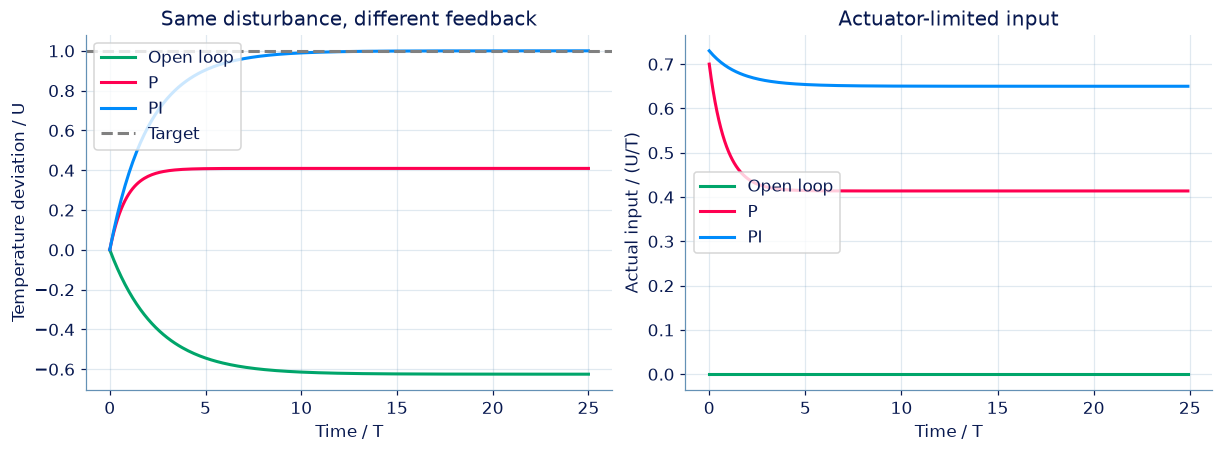

| 方法 | 终点状态 / U | 末步实际输入 / (U/T) |
| --- | --- | --- |
| 开环 | -0.625 | 0 |
| P | 0.4091 | 0.4136 |
| PI | 1 | 0.65 |

In [4]:
h=.1;steps=250;target=1.;disturbance=-.25
def simulate(kp,ki):
    x=0.;I=0.;states=[x];requests=[];actuals=[]
    for _ in range(steps):
        request,u,I=pi_step(target-x,I,h,kp,ki,1.)
        requests.append(request);actuals.append(u)
        x+=h*(-.4*x+u+disturbance);states.append(x)
    return np.array(states),np.array(requests),np.array(actuals)
fig,axes=plt.subplots(1,2,figsize=(11,4))
for kp,ki,name,color in [(0.,0.,'Open loop',GREEN),(.7,0.,'P',PINK),(.7,.3,'PI',BLUE)]:
    state,request,actual=simulate(kp,ki)
    axes[0].plot(np.arange(steps+1)*h,state,label=name,color=color)
    axes[1].plot(np.arange(steps)*h,actual,label=name,color=color)
axes[0].axhline(target,color='gray',ls='--',label='Target');axes[0].set(xlabel='Time / T',ylabel='Temperature deviation / U',title='Same disturbance, different feedback');axes[0].legend()
axes[1].set(xlabel='Time / T',ylabel='Actual input / (U/T)',title='Actuator-limited input');axes[1].legend();plt.show()
display(Markdown(show_table(['方法','终点状态 / U','末步实际输入 / (U/T)'],[(name,*[round(v,4) for v in (simulate(kp,ki)[0][-1],simulate(kp,ki)[2][-1])]) for kp,ki,name in [(0,0,'开环'),(.7,0,'P'),(.7,.3,'PI')]])))

## 结果解释

开环无法补偿持续负扰动；P在该有限增益下留下稳态偏差。PI通过累积误差逐渐增加输入，在本例限幅和增益下接近目标，但初期可能触及限幅。图中方法差异是在固定对象、扰动和执行限制下观察到的，不是PI的普遍保证。

### 独立核对

独立用平衡公式核对P的长时结果；对任意步检查真实输入上限，并与一次条件积分的手算结果对照。

In [5]:
psteady=(.7*target+disturbance)/(.4+.7)
long_p=simulate(.7,0.)[0][-1]
np.testing.assert_allclose(long_p,psteady,atol=3e-4)
assert np.max(np.abs(simulate(.7,.3)[2]))<=1+1e-12
assert pi_step(2.,0.,1.,1.,1.,2.)==(2.,2.,0.)
print('P平衡、限幅与冻结积分手算一致。')

P平衡、限幅与冻结积分手算一致。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/10-01-%E5%BC%80%E9%97%AD%E7%8E%AF%E4%B8%8E%20PID/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：一次 PI 更新

理想温度偏差 e 以 U 计，控制输入（input）以 U/T 计。按题定“条件积分”实现一步：先试算积分；若限幅且当前误差会把请求继续推向限幅，则冻结积分并重新计算请求。返回请求输入、实际输入和积分状态（state）。

**函数与代码模板**

```python
def solve(
    error: float,
    integral: float,
    dt: float,
    kp: float,
    ki: float,
    limit: float,
) -> tuple[float, float, float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `error` | `float` | 当前设定值减测量值。 | U |
| `integral` | `float` | 更新前误差积分。 | U·T |
| `dt` | `float` | 时间步长（time step），严格大于零。 | T |
| `kp` | `float` | 比例增益（gain）。 | 1/T |
| `ki` | `float` | 积分增益。 | 1/T² |
| `limit` | `float` | 执行量绝对值上限，严格大于零。 | U/T |

**返回值**

按以下顺序返回元组：(requested, actual, new_integral)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `requested` | `float` | 冻结判定后的未限幅请求。 | U/T |
| `actual` | `float` | 裁剪到上限后的真实执行输入。 | U/T |
| `new_integral` | `float` | 更新后的误差积分。 | U·T |

**计算规则**

候选 I=I+e·dt；r=kp·e+ki·I。把 r 裁剪到[-limit,limit]。若发生裁剪且 e·r>0，令 I 保持旧值，重新求 r 与实际输入。

**约束与边界**

- 输入均为有限数；只需实现题定模型（model），不外推到真实病人或设备。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| error | 当前设定值减测量值。 | 2 | U |
| integral | 更新前误差积分。 | 0 | U·T |
| dt | 时间步长（time step），严格大于零。 | 1 | T |
| kp | 比例增益（gain）。 | 1 | 1/T |
| ki | 积分增益。 | 1 | 1/T² |
| limit | 执行量绝对值上限，严格大于零。 | 2 | U/T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
error = 2.0
integral = 0.0
dt = 1.0
kp = 1.0
ki = 1.0
limit = 2.0

result = solve(error, integral, dt, kp, ki, limit)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| requested | 冻结判定后的未限幅请求。 | 2 | U/T |
| actual | 裁剪到上限后的真实执行输入。 | 2 | U/T |
| new_integral | 更新后的误差积分。 | 0 | U·T |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (2.0, 2.0, 0.0)
```

**样例解释**

首例候选请求为4，正误差继续推动正限幅，冻结积分后请求与实际输入都为2。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：一次 PI 更新](http://127.0.0.1:8000/chapters/10-01-%E5%BC%80%E9%97%AD%E7%8E%AF%E4%B8%8E%20PID/practice/?question=p10-pi-saturation)

### 第 2 题 · 多项选择题：恒定扰动下的 P 与 PI

对象为稳定一阶线性模型（model），控制方向正确且没有执行饱和。负向恒定扰动持续存在，哪些判断成立？

- **A.** P 控制通常可能留下稳态误差。
- **B.** 增加积分项可在闭环稳定等条件下消除该类常值误差。
- **C.** 只要加积分，无论延迟（delay）与限幅如何，闭环一定稳定。
- **D.** 负反馈（negative feedback）方向的定义必须和误差、执行作用方向一致。

[作答：恒定扰动下的 P 与 PI](http://127.0.0.1:8000/chapters/10-01-%E5%BC%80%E9%97%AD%E7%8E%AF%E4%B8%8E%20PID/practice/?question=p10-pi-constant-load)

### 第 3 题 · 单项选择题：要求与执行不能混用

控制器请求 8 U/T，执行器只能给到 5 U/T。仿真中哪项做法正确？

- **A.** 以8推进对象，并只在图上把输入（input）画成5。
- **B.** 以真实执行的5推进对象，并另存请求的8用于诊断饱和。
- **C.** 对象状态（state）会自动知道控制器原来的请求。
- **D.** 发生饱和后原线性闭环推导仍无条件适用。

[作答：要求与执行不能混用](http://127.0.0.1:8000/chapters/10-01-%E5%BC%80%E9%97%AD%E7%8E%AF%E4%B8%8E%20PID/practice/?question=p10-request-vs-actuation)

### 第 4 题 · 单项选择题：增益有单位

e 单位 U，时间单位 T，执行输入（input）单位 U/T。对 u=kp e+ki∫e dt，哪组增益（gain）单位一致？

- **A.** kp 为1/T，ki 为1/T²。
- **B.** kp 为T，ki 为T²。
- **C.** 两者均为1/T。
- **D.** 增益永远无量纲（dimensionless）。

[作答：增益有单位](http://127.0.0.1:8000/chapters/10-01-%E5%BC%80%E9%97%AD%E7%8E%AF%E4%B8%8E%20PID/practice/?question=p10-gain-units)

**进一步阅读**

[MIT OpenCourseWare，Feedback Control Systems 课程讲义](https://ocw.mit.edu/courses/16-30-feedback-control-systems-fall-2010/pages/lecture-notes/)：按主题阅读 PID、频域、能控、观测器和线性二次调节；本教材的模型与数值为独立教学例。